In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from models_pipe import train_tree_models, evaluate_model, tsne_visual, extract_misclass
from data_preprocessing import radiomics_load, train_test_split, preprocess_train, preprocess_test
from models_pipe import train_pipe, cross_val
from pathlib import Path
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

In [2]:
cleared_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data.csv")
cleared_data1 = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")

display(cleared_data.head(),
        cleared_data1.head())

,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,phase_timing,is_lesionfree,...,XRayTubeCurrent,XRayExposure,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase
0,../DICOM-batch1\NKI-d23231-00-0063\20120416 CT...,DICOM-batch1-kalina01,NET_0000_0000.nii.gz,NKI-d23231-00-0063,2012-04-16,NET_0000_0000.nii.gz,Partially,Arterial,Too Early,No,...,150.0,75.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,40231.70000,Arterial
1,../DICOM-batch1\NKI-d23231-00-0070\20150821 CT...,DICOM-batch1-kalina01,NET_0001_0000.nii.gz,NKI-d23231-00-0070,2015-08-21,NET_0001_0000.nii.gz,Yes,Non-contrast,Non-contrast,No,...,76.0,38.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,LEVER,NaN,1.0,30853.90000,Non-contrast
2,../DICOM-batch1\NKI-d23231-00-0036\20140218 CT...,DICOM-batch1-kalina01,NET_0002_0000.nii.gz,NKI-d23231-00-0036,2014-02-18,NET_0002_0000.nii.gz,Yes,Portal,Just Right,Yes,...,75.0,37.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,32599.60000,NaN
3,../DICOM-batch1\NKI-d23231-00-0071\20130924 CT...,DICOM-batch1-kalina01,NET_0003_0000.nii.gz,NKI-d23231-00-0071,2013-09-24,NET_0003_0000.nii.gz,Yes,Arterial,Just Right,Yes,...,168.0,84.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,45013.30692,NaN
4,../DICOM-batch1\NKI-d23231-00-0077\20141222 CT...,DICOM-batch1-kalina01,NET_0004_0000.nii.gz,NKI-d23231-00-0077,2014-12-22,NET_0004_0000.nii.gz,Yes,Portal,Just Right,No,...,119.0,74.0,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,51587.10418,Portal


,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server
0,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,../DICOM-batch1\NKI-d23231-00-0063\20120416 CT...,DICOM-batch1-kalina01,NET_0000_0000.nii.gz,NKI-d23231-00-0063,2012-04-16,NET_0000_0000.nii.gz,Partially,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,40231.70000,Arterial,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
1,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,../DICOM-batch1\NKI-d23231-00-0070\20150821 CT...,DICOM-batch1-kalina01,NET_0001_0000.nii.gz,NKI-d23231-00-0070,2015-08-21,NET_0001_0000.nii.gz,Yes,Non-contrast,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,LEVER,NaN,1.0,30853.90000,Non-contrast,NKI-d23231-00-0070_20150821_kalina01_0001.nii.gz,NaN
2,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,../DICOM-batch1\NKI-d23231-00-0036\20140218 CT...,DICOM-batch1-kalina01,NET_0002_0000.nii.gz,NKI-d23231-00-0036,2014-02-18,NET_0002_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,32599.60000,NaN,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,../DICOM-batch1\NKI-d23231-00-0071\20130924 CT...,DICOM-batch1-kalina01,NET_0003_0000.nii.gz,NKI-d23231-00-0071,2013-09-24,NET_0003_0000.nii.gz,Yes,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,45013.30692,NaN,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,../DICOM-batch1\NKI-d23231-00-0077\20141222 CT...,DICOM-batch1-kalina01,NET_0004_0000.nii.gz,NKI-d23231-00-0077,2014-12-22,NET_0004_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,51587.10418,Portal,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [3]:
data = cleared_data1.merge(cleared_data['Original File'], how ='right', on = 'Original File')
data.head()

,NiiFile,SegNiiFile,Original File,Destination Folder,New File,SubjectKeyRadiology,ExamDate,file,is_liver_imaged,contrast,...,ImageOrientationPatientDICOM,ConversionSoftware,ConversionSoftwareVersion,BodyPartExamined,RawImage,SliceThickness,AcquisitionTime_sec,DICOM_phase,MatchKey,exist_on_server
0,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0000_00...,../DICOM-batch1\NKI-d23231-00-0063\20120416 CT...,DICOM-batch1-kalina01,NET_0000_0000.nii.gz,NKI-d23231-00-0063,2012-04-16,NET_0000_0000.nii.gz,Partially,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,40231.70000,Arterial,NKI-d23231-00-0063_20120416_kalina01_0000.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
1,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0001_00...,../DICOM-batch1\NKI-d23231-00-0070\20150821 CT...,DICOM-batch1-kalina01,NET_0001_0000.nii.gz,NKI-d23231-00-0070,2015-08-21,NET_0001_0000.nii.gz,Yes,Non-contrast,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,LEVER,NaN,1.0,30853.90000,Non-contrast,NKI-d23231-00-0070_20150821_kalina01_0001.nii.gz,NaN
2,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0002_00...,../DICOM-batch1\NKI-d23231-00-0036\20140218 CT...,DICOM-batch1-kalina01,NET_0002_0000.nii.gz,NKI-d23231-00-0036,2014-02-18,NET_0002_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.0,32599.60000,NaN,NKI-d23231-00-0036_20140218_kalina01_0002.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
3,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0003_00...,../DICOM-batch1\NKI-d23231-00-0071\20130924 CT...,DICOM-batch1-kalina01,NET_0003_0000.nii.gz,NKI-d23231-00-0071,2013-09-24,NET_0003_0000.nii.gz,Yes,Arterial,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,45013.30692,NaN,NKI-d23231-00-0071_20130924_kalina01_0003.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...
4,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,Z:\_archived\DICOM-batch1-kalina01\NET_0004_00...,../DICOM-batch1\NKI-d23231-00-0077\20141222 CT...,DICOM-batch1-kalina01,NET_0004_0000.nii.gz,NKI-d23231-00-0077,2014-12-22,NET_0004_0000.nii.gz,Yes,Portal,...,"[1, 0, 0, 0, 1, 0]",dcm2niix,v1.0.20230411,ABDOMEN,NaN,1.5,51587.10418,Portal,NKI-d23231-00-0077_20141222_kalina01_0004.nii.gz,\\nki.nl\res\RD CRC-data\_archive\IRBd23231-AM...


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8708 entries, 0 to 8707
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   NiiFile                             8708 non-null   str    
 1   SegNiiFile                          8708 non-null   str    
 2   Original File                       8708 non-null   str    
 3   Destination Folder                  8708 non-null   str    
 4   New File                            8708 non-null   str    
 5   SubjectKeyRadiology                 8708 non-null   str    
 6   ExamDate                            8708 non-null   str    
 7   file                                8708 non-null   str    
 8   is_liver_imaged                     8547 non-null   str    
 9   contrast                            8708 non-null   str    
 10  phase_timing                        8708 non-null   str    
 11  is_lesionfree                       8708 non-null   st

In [5]:
data.to_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_2.csv", index=False)

In [6]:
data_dir = Path("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_2.csv")

features_dir = Path("/projects/net_contrast_classification/contrast_phase/Radiomics/features")

radiomics = radiomics_load(data_dir, features_dir)
radiomics

,image,SubjectKeyRadiology,phase_timing,contrast,organ,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,...,original_glcm_Correlation,original_glcm_Autocorrelation,original_glcm_ClusterTendency,original_glcm_DifferenceEntropy,original_glszm_ZoneEntropy,original_glszm_SmallAreaEmphasis,original_glszm_GrayLevelNonUniformity,original_glszm_SizeZoneNonUniformity,original_gldm_SmallDependenceEmphasis,original_gldm_DependenceNonUniformity
0,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,spleen,73.0,129.0,1.411073e+09,2.345055,28.0,...,0.331391,161.467821,4.317435,1.807917,5.579062,0.607571,789.747481,2234.026508,0.057494,8059.752032
1,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_right,35.0,174.0,2.051722e+09,3.368361,96.0,...,0.573631,172.405745,24.124352,2.463745,5.972511,0.623694,1069.817432,4300.504964,0.100165,11505.342655
2,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,kidney_left,29.0,175.0,1.875893e+09,3.462463,101.0,...,0.625287,168.789858,27.864372,2.459546,5.964703,0.651090,921.112624,4496.306967,0.102064,10496.241509
3,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,gallbladder,15.0,92.0,6.779767e+06,2.671679,44.0,...,0.277793,49.512989,6.008309,2.088526,5.214034,0.571997,22.650794,58.957672,0.102627,169.717503
4,NKI-d23231-00-0510_20190509_kalina99_3510.nii.gz,NKI-d23231-00-0510,Just Right,Arterial,liver,57.0,111.0,9.182282e+09,2.273400,28.0,...,0.304811,769.295507,3.639820,1.789879,5.516856,0.589709,7598.796877,15753.440790,0.049232,79966.681546
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166655,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,portal_vein_and_splenic_vein,94.0,199.0,3.244518e+08,2.985268,54.0,...,0.441004,162.569181,11.146397,2.231316,5.916112,0.579998,180.277874,546.459272,0.132850,1009.163186
166656,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_left,47.0,169.0,1.198564e+08,3.299687,60.0,...,0.538260,169.284619,19.404490,2.269254,6.271613,0.553009,87.013220,307.181303,0.143030,577.424611
166657,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_artery_right,47.0,167.0,2.443429e+08,3.426126,67.0,...,0.574321,193.314195,96.147512,2.481168,6.542065,0.607940,99.914074,464.976296,0.155215,700.690310
166658,NKI-d23231-00-0521_20180208_kalina99_3587.nii.gz,NKI-d23231-00-0521,Just Right,Portal,iliac_vena_left,26.0,122.0,1.316743e+08,3.136003,42.0,...,0.626491,113.830952,18.455433,2.138249,6.222564,0.600864,131.003509,578.122807,0.110335,1047.527077


In [7]:
radiomics.info()

<class 'pandas.DataFrame'>
RangeIndex: 166660 entries, 0 to 166659
Data columns (total 34 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   image                                            166660 non-null  str    
 1   SubjectKeyRadiology                              166460 non-null  str    
 2   phase_timing                                     166460 non-null  str    
 3   contrast                                         166660 non-null  str    
 4   organ                                            166660 non-null  str    
 5   original_firstorder_10Percentile                 146636 non-null  float64
 6   original_firstorder_90Percentile                 146636 non-null  float64
 7   original_firstorder_Energy                       146636 non-null  float64
 8   original_firstorder_Entropy                      146636 non-null  float64
 9   original_firstorder_Interq

In [8]:
radiomics = radiomics[radiomics['SubjectKeyRadiology'].notna()]

In [9]:
train_data, test_data = train_test_split(radiomics, test_size=0.3, grouping="SubjectKeyRadiology")

meta_cols = list(train_data.iloc[:, :5].columns)

train_pipeline = preprocess_train(train_data, meta_cols,NA_filter_threshold=0.2, pca_components=30)

train_processed = train_pipeline["data_processed"]
X_train_pca = train_pipeline["X_pca"]
test_processed, X_test_pca = preprocess_test(test_data, meta_cols,train_pipeline)

# Contrast Classification

## Modeling and Evaluation

In [10]:
contrast_le = LabelEncoder()

X_train, y_train = train_processed.iloc[:, 4:], contrast_le.fit_transform(train_processed.contrast)
X_test, y_test = test_processed.iloc[:, 4:], contrast_le.fit_transform(test_processed.contrast)

print(f"Shape of train data: {X_train.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {X_test.shape}\nShape of test labels: {y_test.shape}")


Shape of train data: (5664, 212)
Shape of train labels: (5664,)
Shape of test data: (2659, 212)
Shape of test labels: (2659,)


In [11]:
models = train_tree_models(X_train, y_train)
predictions,_ = evaluate_model(models, X_test, y_test, contrast_le)

Accuracy of DT: 0.96126
Accuracy of RF: 0.97292
Accuracy of GBT: 0.97744

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.98      0.95      0.97       776
Non-contrast       1.00      0.99      0.99       683
      Portal       0.96      0.99      0.98      1200

    accuracy                           0.98      2659
   macro avg       0.98      0.98      0.98      2659
weighted avg       0.98      0.98      0.98      2659



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,739,0,37,776
Non-contrast,0,677,6,683
Portal,14,3,1183,1200
All,753,680,1226,2659


In [24]:
# TEST ON A RANDOM SUBSET OF 20 FEATURES 

subset = np.random.choice(X_train.columns, 20, replace=False)
models = train_tree_models(X_train[subset], y_train)

model = models['GBT']
pred = model.predict(X_test[subset])

print(classification_report(y_test, pred, target_names=contrast_le.classes_))

              precision    recall  f1-score   support

    Arterial       0.91      0.90      0.91       776
Non-contrast       0.98      0.97      0.97       683
      Portal       0.93      0.94      0.93      1200

    accuracy                           0.93      2659
   macro avg       0.94      0.94      0.94      2659
weighted avg       0.93      0.93      0.93      2659



## Cross Validation

In [6]:
acc = cross_val(radiomics,
                 ["image", "SubjectKeyRadiology", "phase_timing", "contrast", "organ"],
                   class_name = "contrast",
                     model_name = "GBT")

Accuracy of DT: 0.96096
Accuracy of RF: 0.97177
Accuracy of GBT: 0.97598

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.97      0.96      0.96       497
Non-contrast       1.00      0.99      0.99       427
      Portal       0.96      0.98      0.97       741

    accuracy                           0.98      1665
   macro avg       0.98      0.98      0.98      1665
weighted avg       0.98      0.98      0.98      1665



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,475,0,22,497
Non-contrast,1,421,5,427
Portal,12,0,729,741
All,488,421,756,1665


Accuracy of DT: 0.96232
Accuracy of RF: 0.96950
Accuracy of GBT: 0.97129

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.98      0.93      0.96       500
Non-contrast       1.00      0.99      0.99       429
      Portal       0.95      0.99      0.97       743

    accuracy                           0.97      1672
   macro avg       0.98      0.97      0.97      1672
weighted avg       0.97      0.97      0.97      1672



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,467,0,33,500
Non-contrast,1,424,4,429
Portal,9,1,733,743
All,477,425,770,1672


Accuracy of DT: 0.96577
Accuracy of RF: 0.97477
Accuracy of GBT: 0.97598

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.98      0.95      0.96       496
Non-contrast       0.99      0.99      0.99       427
      Portal       0.97      0.98      0.97       742

    accuracy                           0.98      1665
   macro avg       0.98      0.98      0.98      1665
weighted avg       0.98      0.98      0.98      1665



...

Accuracy of DT: 0.94708
Accuracy of RF: 0.96993
Accuracy of GBT: 0.96512

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.95      0.93      0.94       497
Non-contrast       1.00      1.00      1.00       426
      Portal       0.95      0.97      0.96       740

    accuracy                           0.97      1663
   macro avg       0.97      0.97      0.97      1663
weighted avg       0.97      0.97      0.97      1663



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,464,0,33,497
Non-contrast,1,424,1,426
Portal,21,2,717,740
All,486,426,751,1663


Accuracy of DT: 0.95204
Accuracy of RF: 0.96583
Accuracy of GBT: 0.97122

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.99      0.92      0.96       497
Non-contrast       1.00      0.99      0.99       429
      Portal       0.95      0.99      0.97       742

    accuracy                           0.97      1668
   macro avg       0.98      0.97      0.97      1668
weighted avg       0.97      0.97      0.97      1668



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,459,0,38,497
Non-contrast,1,424,4,429
Portal,3,2,737,742
All,463,426,779,1668


GBT accuracy: 0.972 ± 0.004


## Explanations

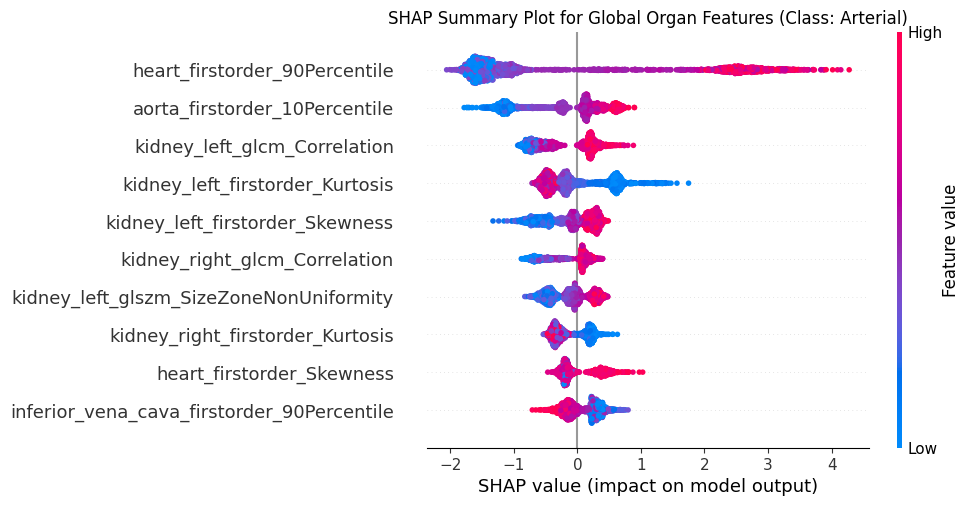

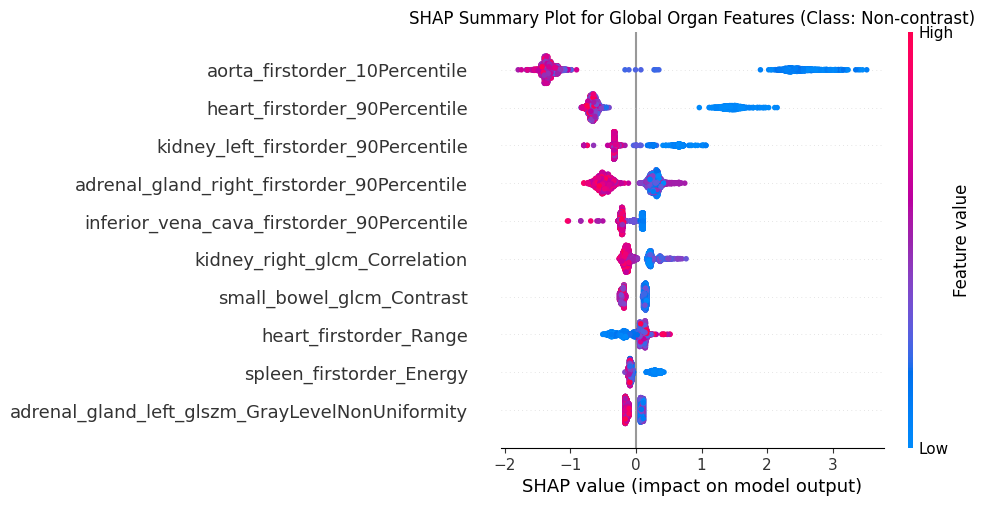

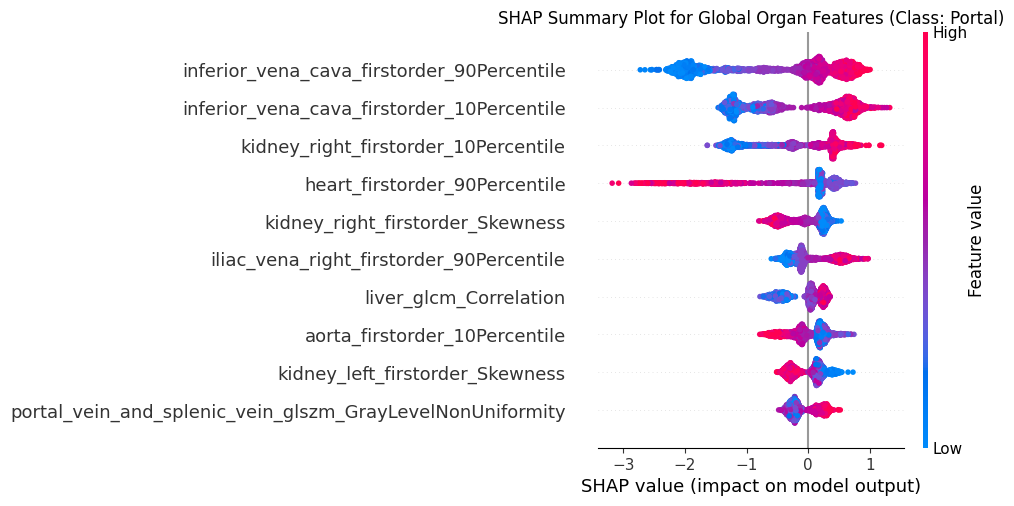

In [12]:
GBT = models['GBT']

explainer = shap.TreeExplainer(GBT)
shap_values = explainer(X_test)


for contrast_class in range(len(contrast_le.classes_)):
    shap.summary_plot(
        shap_values.values[:, :, contrast_class]
        , X_test
        , max_display = 10
        , feature_names=X_test.columns
        , plot_size=(10, 5)
        , show = False

    )

    plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {contrast_le.classes_[contrast_class]})", fontsize=12)
    plt.show()

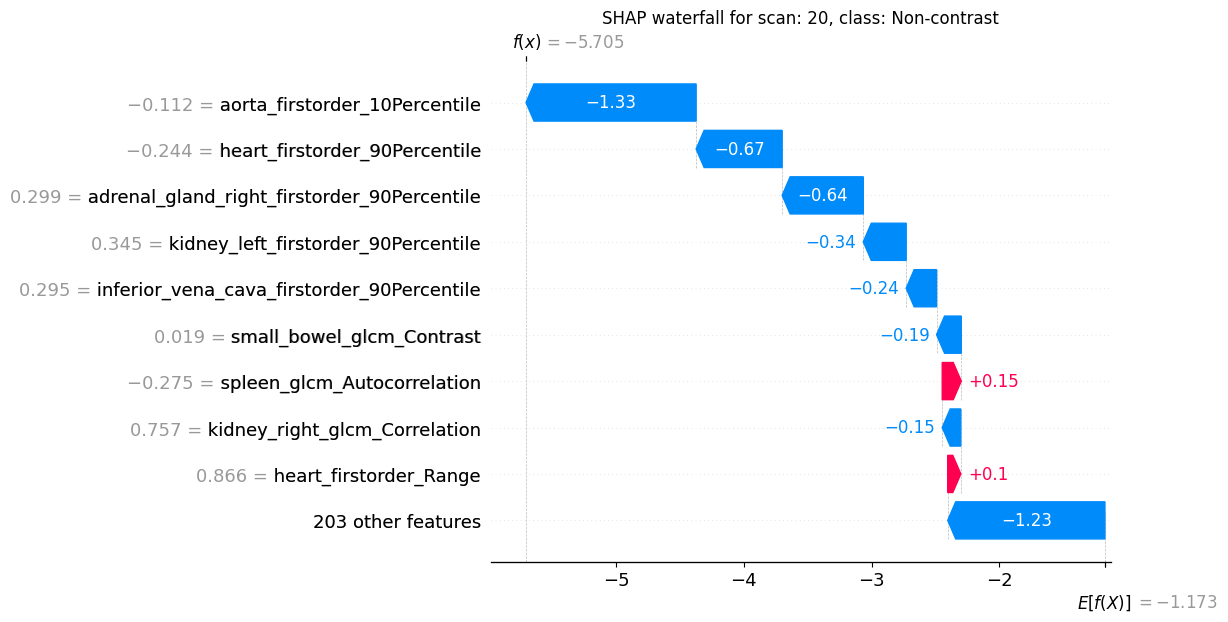

In [13]:
i = 20  # index of sample => 1st sample
class_idx = 1

exp = shap.Explanation(
    values = shap_values.values[i, :, class_idx],
    base_values = shap_values.base_values[i, class_idx],
    data = X_test.iloc[i],
    feature_names = X_test.columns
)

plt.title(f"SHAP waterfall for scan: {i}, class: {contrast_le.classes_[class_idx]}", fontsize=12)
shap.plots.waterfall(exp)

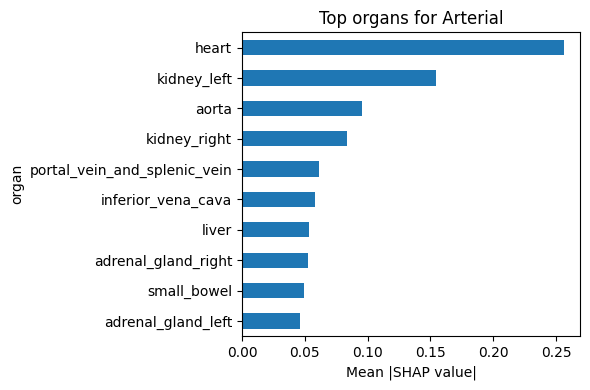

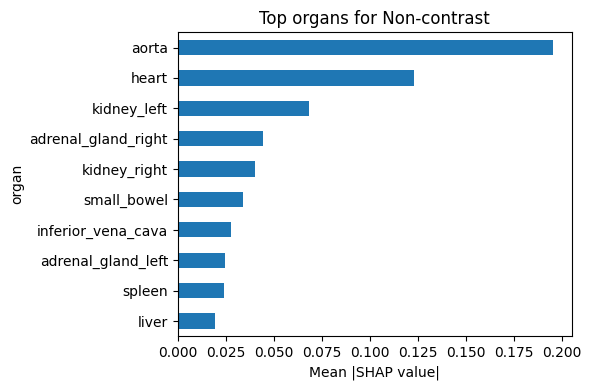

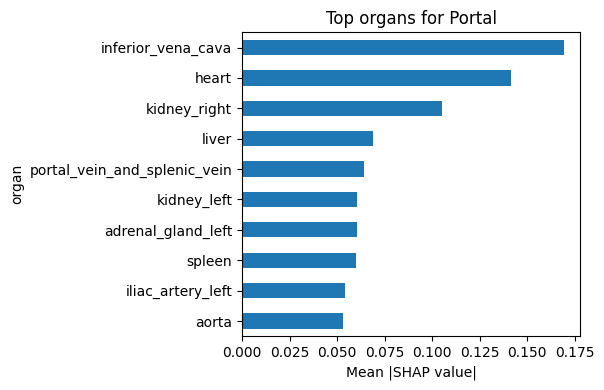


Top organs for ARTERIAL (vs portal):
                              arterial    portal  difference
organ                                                       
heart                         0.256260  0.141327    0.114933
kidney_left                   0.154118  0.060686    0.093431
aorta                         0.095668  0.053024    0.042644
small_bowel                   0.049591  0.039470    0.010121
iliac_vena_left               0.040873  0.035462    0.005411
adrenal_gland_right           0.052584  0.047592    0.004992
pancreas                      0.042426  0.040341    0.002084
iliac_artery_right            0.029302  0.027647    0.001655
portal_vein_and_splenic_vein  0.060972  0.064318   -0.003346
stomach                       0.024827  0.028513   -0.003686

Top organs for PORTAL (vs arterial):
                    arterial    portal  difference
organ                                             
inferior_vena_cava  0.057874  0.169272   -0.111398
iliac_vena_right    0.022501  0.046905 

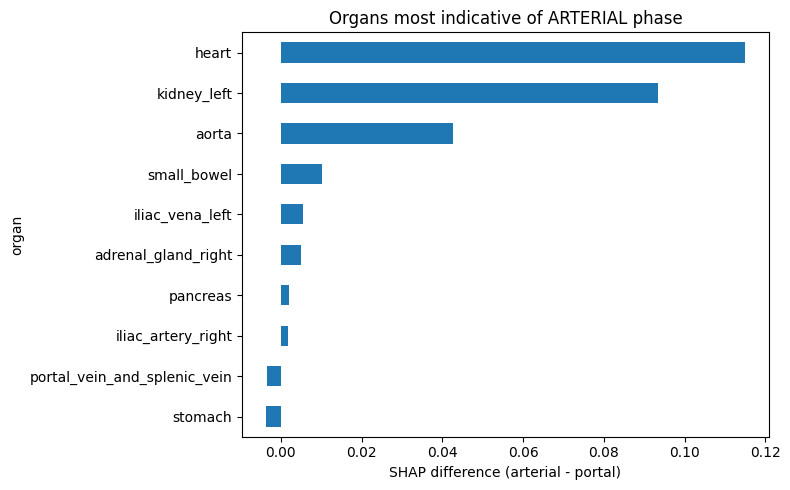

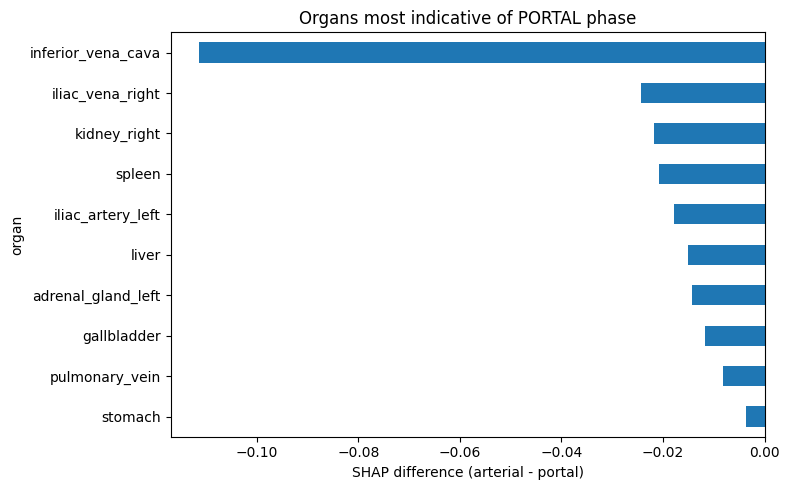

<Figure size 1000x500 with 0 Axes>

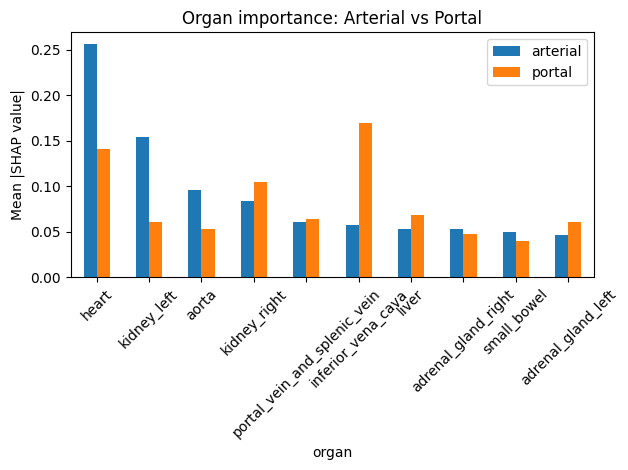

In [14]:
feature_names = X_test.columns
import re

def extract_organ(feature_name):
    match = re.split(r'_(firstorder|glcm|glrlm|glszm|gldm|ngtdm|shape)', feature_name)
    return match[0]

organ_names = [extract_organ(col) for col in X_test.columns]


organ_importance_per_class = {}

for class_idx, class_name in enumerate(contrast_le.classes_):

    shap_class = shap_values.values[:, :, class_idx]

    # Mean absolute SHAP per feature
    mean_shap = np.abs(shap_class).mean(axis=0)

    df = pd.DataFrame({
        "feature": feature_names,
        "organ": organ_names,
        "importance": mean_shap
    })

    # Aggregate per organ (mean is preferred)
    organ_importance = (
        df.groupby("organ")["importance"]
        .mean()
        .sort_values(ascending=False)
    )

    organ_importance_per_class[class_name] = organ_importance

    # ----------------------------
    # Plot top organs per class
    # ----------------------------
    plt.figure(figsize=(6, 4))
    organ_importance.head(10).plot(kind="barh")
    plt.gca().invert_yaxis()
    plt.title(f"Top organs for {class_name}")
    plt.xlabel("Mean |SHAP value|")
    plt.tight_layout()
    plt.show()


# ----------------------------
# 3. Arterial vs Portal comparison
# ----------------------------
classes = list(contrast_le.classes_)

arterial_idx = classes.index("Arterial")
portal_idx = classes.index("Portal")

shap_art = np.abs(shap_values.values[:, :, arterial_idx]).mean(axis=0)
shap_port = np.abs(shap_values.values[:, :, portal_idx]).mean(axis=0)

df_compare = pd.DataFrame({
    "feature": feature_names,
    "organ": organ_names,
    "arterial": shap_art,
    "portal": shap_port
})

# Aggregate per organ
organ_compare = df_compare.groupby("organ")[["arterial", "portal"]].mean()

# Difference (positive = more important for arterial)
organ_compare["difference"] = organ_compare["arterial"] - organ_compare["portal"]

# ----------------------------
# 4. Print top discriminative organs
# ----------------------------
print("\nTop organs for ARTERIAL (vs portal):")
print(organ_compare.sort_values("difference", ascending=False).head(10))

print("\nTop organs for PORTAL (vs arterial):")
print(organ_compare.sort_values("difference", ascending=True).head(10))


# ----------------------------
# 5. Plot comparison
# ----------------------------
plt.figure(figsize=(8, 5))
organ_compare.sort_values("difference", ascending=False).head(10)["difference"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Organs most indicative of ARTERIAL phase")
plt.xlabel("SHAP difference (arterial - portal)")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
organ_compare.sort_values("difference", ascending=True).head(10)["difference"].plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Organs most indicative of PORTAL phase")
plt.xlabel("SHAP difference (arterial - portal)")
plt.tight_layout()
plt.show()


# ----------------------------
# 6. Side-by-side plot
# ----------------------------
top_organs = organ_compare.sort_values("arterial", ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_organs[["arterial", "portal"]].plot(kind="bar")
plt.title("Organ importance: Arterial vs Portal")
plt.ylabel("Mean |SHAP value|")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Visualizations

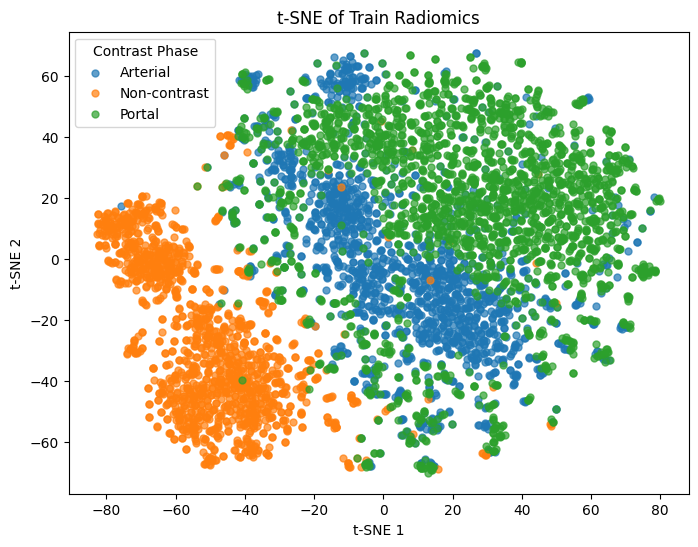

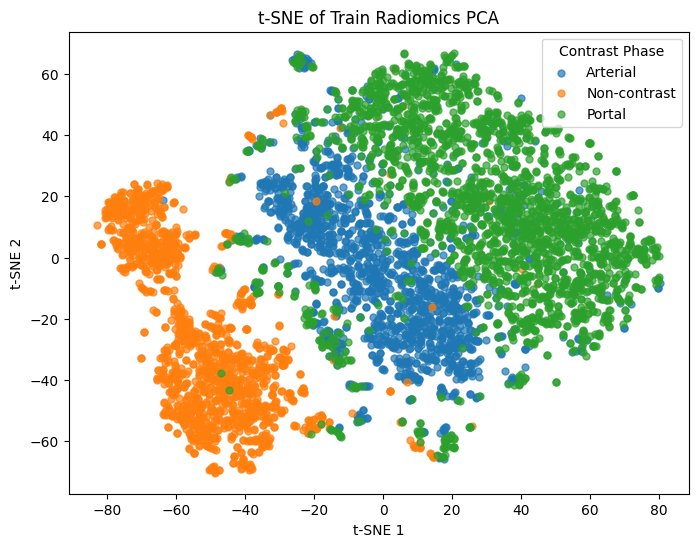

In [15]:
tsne_visual(X_train, y_train, contrast_le, "t-SNE of Train Radiomics")
tsne_visual(X_train_pca, y_train, contrast_le, "t-SNE of Train Radiomics PCA")

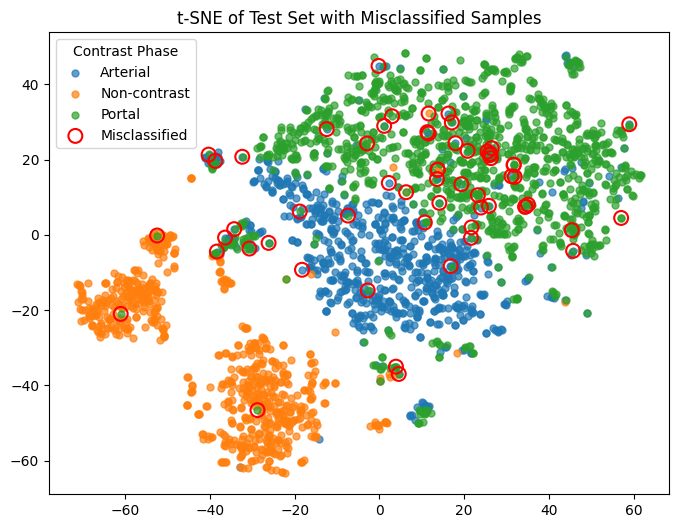

In [16]:
GBT_pred = predictions["GBT"]

tsne_visual(X_test_pca,
            y_test,
            contrast_le,
            "t-SNE of Test Radiomics PCA with Misclassifications",
            misclassifications=True,
            predictions=GBT_pred)

## Misclassifications

In [18]:
GBT_pred = predictions["GBT"]

In [19]:

def window_ct(img, center = 50, width = 300):
        low = center - width/2
        high = center + width/2
        return img.clip(low, high)

def show_misclass(misclass_data, orig_data, samples_per_class=3, label = 'contrast'):
    """
    Display misclassified images with true and predicted labels using
    'contrast' and 'pred_contrast' columns in misclass_data.

    misclass_data: pd.DataFrame
        Must contain 'MatchKey', 'contrast', and 'pred_contrast'.
    orig_data: pd.DataFrame
        Original dataframe with 'MatchKey' and 'server_folder'.
    samples_per_class: int
        Number of images to show per class.
    """

    # Merge folder paths
    misclass_data = misclass_data.merge(orig_data[['MatchKey', 'server_folder']], on='MatchKey', how='left')

    # Sample images per class
    rows = []
    for c in misclass_data[label].unique():
        subset = misclass_data[misclass_data[label] == c]
        rows.append(subset.sample(n=min(samples_per_class, len(subset))))

    selected_rows = pd.concat(rows).sort_values(label).reset_index(drop=True)

    file_list = selected_rows.MatchKey.tolist()
    folder_list = selected_rows.server_folder.tolist()

    # Load images
    images, _ = data_load(file_list, folder_list, organ_seg=False)

    

    # Plot images
    for _, group in selected_rows.groupby(label):

        plt.figure(figsize=(15, 5))

        for j, idx in enumerate(group.index):
            img = images[idx][0]
            slice_img = img[:, :, int(img.shape[-1] // 1.3)]

            plt.subplot(1, len(group), j + 1)
            plt.imshow(np.rot90(window_ct(slice_img), 1), cmap="gray")

            # Use contrast and pred_contrast columns
            true_label = selected_rows.loc[idx, label]
            pred_label = selected_rows.loc[idx, "pred_contrast"]
            plt.title(f"True:{true_label}\nPred: {pred_label}")
            plt.axis("off")

        plt.show()


In [20]:
import ipywidgets as widgets
from IPython.display import display
from radiomics_pipeline import data_load

def show_misclass_widget(misclass_data, orig_data, samples_per_class=3, label='contrast'):
    """
    Display misclassified images with an interactive slice slider.
    """

    # Merge folder paths
    misclass_data = misclass_data.merge(orig_data[['MatchKey', 'server_folder']], left_on="image", right_on='MatchKey', how='left')

    # Sample images per class
    rows = []
    for c in misclass_data[label].unique():
        subset = misclass_data[misclass_data[label] == c]
        rows.append(subset.sample(n=min(samples_per_class, len(subset))))

    selected_rows = pd.concat(rows).sort_values(label).reset_index(drop=True)

    file_list = selected_rows.image.tolist()
    folder_list = selected_rows.server_folder.tolist()

    # Load images
    images, _ = data_load(file_list, folder_list, organ_seg=False)

    max_slices = max(img[0].shape[-1] for img in images)

    # Create a slice slider widget
    slice_slider = widgets.IntSlider(
        value=max_slices // 2,
        min=0,
        max=max_slices - 1,
        step=1,
        description="Slice"
    )

    def update(slice_idx):
        """Redraw images for selected slice."""
        for _, group in selected_rows.groupby(label):
            plt.figure(figsize=(15, 5))

            for j, idx in enumerate(group.index):
                img = images[idx][0]
                slice_idx_use = min(slice_idx, img.shape[-1] - 1)
                slice_img = img[:, :, slice_idx_use]

                plt.subplot(1, len(group), j + 1)
                plt.imshow(np.rot90(window_ct(slice_img), 1), cmap="gray")

                true_label = selected_rows.loc[idx, label]
                pred_label = selected_rows.loc[idx, "pred_contrast"]
                plt.title(f"True:{true_label}\nPred: {pred_label}")
                plt.axis("off")

            plt.show()

    # Use interactive widget
    widgets.interact(update, slice_idx=slice_slider)

In [17]:
misclass_data = extract_misclass(
    y_test,
    GBT_pred,  
    test_processed,  
    contrast_le,                  
    X_test.index                # important
)
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,pred_contrast
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.454899,1.187198,0.825683,0.089085,0.181119,0.852501,...,1.296382,-0.157163,0.252880,-0.014708,-0.084282,0.828090,0.344827,-0.105244,0.711120,Portal
29,NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz,NKI-d23231-00-0010,Just Right,Portal,-0.256865,-0.934769,-0.860664,-0.803112,-0.138793,0.230633,...,-1.386193,-0.375761,0.154181,0.105329,-0.919934,-0.146522,-0.766854,-0.390854,-0.813061,Non-contrast
141,NKI-d23231-00-0052_20130412_kalina14_0020.nii.gz,NKI-d23231-00-0052,Just Right,Portal,-0.962747,0.513557,-0.143907,1.575463,-0.530716,-0.295563,...,-0.772882,-0.285893,0.203530,-1.535175,0.639415,-1.451921,0.367432,1.619752,0.519785,Arterial
160,NKI-d23231-00-0052_20210402_kalina13_0004.nii.gz,NKI-d23231-00-0052,Just Right,Arterial,-1.139217,-0.463221,-0.956968,0.780556,-0.550609,-0.080301,...,-1.190661,-0.400049,-0.117242,-0.054720,0.521324,-1.484503,-0.009345,3.037109,1.534112,Portal
192,NKI-d23231-00-0053_20100427_kalina15_0015.nii.gz,NKI-d23231-00-0053,Just Right,Arterial,-1.880393,3.073390,1.079406,3.716951,-0.583900,-2.663444,...,1.632165,0.158589,0.384479,0.105329,0.386714,0.191702,0.073744,0.238043,0.510684,Portal


In [24]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/TS/TS_results.csv")
data['server_folder'] = np.where(
    data['exist_on_server'].notna(),
    "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET",
    "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server"
)

data['server_folder'].value_counts()

server_folder
/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET                  5447
/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server    3287
Name: count, dtype: int64

In [25]:
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,pred_contrast
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.455424,1.188326,0.826744,0.089149,0.181125,0.852617,...,1.296723,-0.157163,0.252907,-0.015016,-0.084225,0.828376,0.345143,-0.105911,0.710870,Portal
28,NKI-d23231-00-0010_20070213_kalina04_0018.nii.gz,NKI-d23231-00-0010,Too Early,Arterial,-0.044578,-0.698770,-0.655509,-0.732590,0.057062,-0.175637,...,-1.496633,-0.322400,0.187065,0.105089,-0.993516,0.220498,-1.367523,-0.573770,-0.958453,Non-contrast
29,NKI-d23231-00-0010_20070213_kalina05_0018.nii.gz,NKI-d23231-00-0010,Just Right,Portal,-0.256343,-0.934657,-0.860420,-0.802878,-0.138920,0.230882,...,-1.386033,-0.375860,0.154143,0.105089,-0.920018,-0.146407,-0.766564,-0.391359,-0.813451,Non-contrast
141,NKI-d23231-00-0052_20130412_kalina14_0020.nii.gz,NKI-d23231-00-0052,Just Right,Portal,-0.962226,0.514363,-0.143315,1.575243,-0.531005,-0.295201,...,-0.772681,-0.285951,0.203525,-1.536351,0.639594,-1.452037,0.367749,1.618108,0.519518,Arterial
160,NKI-d23231-00-0052_20210402_kalina13_0004.nii.gz,NKI-d23231-00-0052,Just Right,Arterial,-1.138697,-0.462883,-0.956771,0.780488,-0.550906,-0.079986,...,-1.190488,-0.400159,-0.117459,-0.055052,0.521483,-1.484624,-0.009037,3.034663,1.533938,Portal


In [18]:
show_misclass_widget(misclass_data, data)

interactive(children=(IntSlider(value=120, description='Slice', max=240), Output()), _dom_classes=('widget-int…

In [26]:
data.SliceThickness.value_counts()

SliceThickness
1.0    4307
1.5    3343
3.0     719
2.0     320
Name: count, dtype: int64

In [27]:
misclass_data_eval = misclass_data[["image",
                                    "contrast", 
                                    "pred_contrast",
                                    "phase_timing"]].merge(data,
                                                            left_on="image",
                                                            right_on="MatchKey",
                                                            how="left")

misclass_data_eval[["SubjectKeyRadiology",
                    "contrast_x",
                    "phase_timing_x",
                    "pred_contrast",
                    "DICOM_phase",
                    "TS_contrast",
                    "is_lesionfree",
                    "is_liver_imaged",
                    "ProtocolName",
                    "ConvolutionKernel",
                    "AcquisitionTime",
                    "SliceThickness"
                ]]

,SubjectKeyRadiology,contrast_x,phase_timing_x,pred_contrast,DICOM_phase,TS_contrast,is_lesionfree,is_liver_imaged,ProtocolName,ConvolutionKernel,AcquisitionTime,SliceThickness
0,NKI-d23231-00-0005,Arterial,Just Right,Portal,NaN,Portal,Yes,Yes,ABDOMEN + C 1.0 FC01,FC01,12:10:30.950000,1.0
1,NKI-d23231-00-0010,Arterial,Too Early,Non-contrast,Arterial,Portal,No,Yes,Lever A 2mm,B,11:29:4.000000,2.0
2,NKI-d23231-00-0010,Portal,Just Right,Non-contrast,NaN,Arterial,No,Yes,Abdomen +C 2mm,B,11:29:44.000000,2.0
3,NKI-d23231-00-0052,Portal,Just Right,Arterial,NaN,Portal,No,Partially,ABDOMEN + C 1.0 FC02,FC02,11:51:16.250000,1.0
4,NKI-d23231-00-0052,Arterial,Just Right,Portal,NaN,Portal,No,Yes,Body 1.0 CE Vol.,FC01,13:42:23.150000,1.0
5,NKI-d23231-00-0053,Arterial,Just Right,Portal,NaN,Portal,Yes,Partially,Thorax 1.5 B45f,B45f,15:47:35.044780,1.5
6,NKI-d23231-00-0067,Arterial,Just Right,Portal,NaN,Portal,No,Yes,ABDOMEN + C 1.0 FC01,FC01,14:36:27.500000,1.0
7,NKI-d23231-00-0102,Non-contrast,0.0,Portal,NaN,Non-contrast,No,0,Abdomen 1.5 B30f,B30f,15:32:48.225210,1.5
8,NKI-d23231-00-0102,Arterial,Just Right,Portal,NaN,Portal,No,Yes,Lever +C 1.5 B25f,B25f,15:31:46.756630,1.5
9,NKI-d23231-00-0109,Portal,Just Right,Non-contrast,Non-contrast,Non-contrast,No,Yes,Lever -C 1.5 B25f,B25f,15:10:56.432010,1.5


In [28]:
misclass_data_eval.is_lesionfree.value_counts()

is_lesionfree
No     42
Yes    15
Name: count, dtype: int64

In [29]:
misclass_data_eval.high_signal_to_noise.value_counts()

high_signal_to_noise
False    49
True      7
Name: count, dtype: int64

In [30]:
misclass_data_eval[misclass_data_eval.pred_contrast == misclass_data_eval.DICOM_phase][["SubjectKeyRadiology",
                                                                                        "contrast_x",
                                                                                        "pred_contrast",
                                                                                        "DICOM_phase",
                                                                                        "TS_contrast"]]

,SubjectKeyRadiology,contrast_x,pred_contrast,DICOM_phase,TS_contrast
9,NKI-d23231-00-0109,Portal,Non-contrast,Non-contrast,Non-contrast
21,NKI-d23231-00-0223,Arterial,Portal,Portal,Portal
41,NKI-d23231-00-0510,Portal,Arterial,Arterial,Portal
42,NKI-d23231-00-0511,Portal,Arterial,Arterial,Arterial
48,NKI-d23231-00-0610,Portal,Arterial,Arterial,Arterial
50,NKI-d23231-00-0663,Portal,Arterial,Arterial,Portal
55,NKI-d23231-00-0841,Arterial,Portal,Portal,Portal


# Phase Timing Classification

## Modeling and Evaluation

In [19]:
train_data_timing = train_processed[(train_processed.contrast != "Non-contrast") 
                                 & (train_processed.phase_timing != "0.0")]

train_data_timing['contrast_timing'] = (train_data_timing["contrast"].str.cat(train_data_timing["phase_timing"], sep=" "))
train_data_timing["contrast_timing"] = train_data_timing["contrast_timing"].astype(str).str.strip()
print("Train data class distribution:\n",train_data_timing.contrast_timing.value_counts(), "\n")

test_data_timing = test_processed[(test_processed.contrast != "Non-contrast") 
                                 & (test_processed.phase_timing != "0.0")]

test_data_timing['contrast_timing'] = (test_data_timing["contrast"].str.cat(test_data_timing["phase_timing"], sep=" "))
test_data_timing["contrast_timing"] = test_data_timing["contrast_timing"].astype(str).str.strip()
print("Test data class distribution:\n", test_data_timing.contrast_timing.value_counts())

Train data class distribution:
 contrast_timing
Portal Just Right      2380
Arterial Just Right    1076
Arterial Too Early      550
Portal Too Early         83
Arterial Too Late        82
Portal Too Late          38
Name: count, dtype: int64 

Test data class distribution:
 contrast_timing
Portal Just Right      1148
Arterial Just Right     493
Arterial Too Early      248
Portal Too Early         34
Arterial Too Late        33
Portal Too Late          18
Name: count, dtype: int64


In [20]:
timing_le = LabelEncoder()

X_train_timing, y_train_timing = train_data_timing.iloc[:, 4:-1], timing_le.fit_transform(train_data_timing.contrast_timing)
X_test_timing, y_test_timing = test_data_timing.iloc[:, 4:-1], timing_le.fit_transform(test_data_timing.contrast_timing)

print(f"Shape of train data: {X_train_timing.shape}\nShape of train labels: {y_train_timing.shape}")
print(f"Shape of test data: {X_test_timing.shape}\nShape of test labels: {y_test_timing.shape}")

Shape of train data: (4209, 212)
Shape of train labels: (4209,)
Shape of test data: (1974, 212)
Shape of test labels: (1974,)


In [21]:
y_train_timing

array([4, 3, 3, ..., 3, 0, 3])

In [22]:
train_data_timing.contrast_timing

0          Portal Too Early
1         Portal Just Right
3         Portal Just Right
4         Portal Just Right
5         Portal Just Right
               ...         
5659      Portal Just Right
5660    Arterial Just Right
5661      Portal Just Right
5662    Arterial Just Right
5663      Portal Just Right
Name: contrast_timing, Length: 4209, dtype: str

In [23]:
models = train_tree_models(X_train_timing, y_train_timing)
predictions,_ = evaluate_model(models, X_test_timing, y_test_timing, timing_le)

Accuracy of DT: 0.82219
Accuracy of RF: 0.86626
Accuracy of GBT: 0.87943

Classification report for GBT:
                     precision    recall  f1-score   support

Arterial Just Right       0.83      0.84      0.83       493
 Arterial Too Early       0.75      0.78      0.76       248
  Arterial Too Late       0.00      0.00      0.00        33
  Portal Just Right       0.93      0.98      0.96      1148
   Portal Too Early       0.12      0.03      0.05        34
    Portal Too Late       0.00      0.00      0.00        18

           accuracy                           0.88      1974
          macro avg       0.44      0.44      0.43      1974
       weighted avg       0.85      0.88      0.86      1974



Predicted contrast,Arterial Just Right,Arterial Too Early,Arterial Too Late,Portal Just Right,Portal Too Early,Portal Too Late,All
True contrast,,,,,,,
Arterial Just Right,412,62,0,17,2,0,493
Arterial Too Early,52,193,0,3,0,0,248
Arterial Too Late,15,0,0,16,2,0,33
Portal Just Right,11,2,1,1130,2,2,1148
Portal Too Early,2,0,0,31,1,0,34
Portal Too Late,2,0,0,15,1,0,18
All,494,257,1,1212,8,2,1974


### Class weights

In [57]:

# Compute balanced class weights
classes = np.unique(y_train_timing)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train_timing)
sample_weights = np.array([class_weights[c] for c in y_train_timing])
print(class_weights)
print(sample_weights)


# Train XGBClassifier
model = XGBClassifier(
    objective="multi:softprob",
    num_class=6,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)

model.fit(X_train_timing, y_train_timing, sample_weight=sample_weights)

# Predictions
y_pred_probs = model.predict_proba(X_test_timing)  # shape: (n_samples, 6)
y_pred = y_pred_probs.argmax(axis=1)


print(classification_report(y_test_timing, y_pred))

[ 0.65257125  1.27666667  8.56300813  0.2947803   8.45983936 17.55416667]
[8.45983936 0.2947803  0.2947803  ... 0.2947803  0.65257125 0.2947803 ]
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       493
           1       0.72      0.79      0.75       248
           2       0.50      0.09      0.15        33
           3       0.94      0.98      0.96      1150
           4       0.17      0.06      0.09        34
           5       0.17      0.06      0.08        18

    accuracy                           0.88      1976
   macro avg       0.55      0.46      0.48      1976
weighted avg       0.86      0.88      0.86      1976



### Ordinal Regression

In [41]:
phase_mapping = {"Arterial Too Early": 0,
                 "Arterial Just Right": 1,
                 "Arterial Too Late": 2,
                 "Portal Too Early": 3,
                 "Portal Just Right": 4,
                 "Portal Too Late": 5,
                 }


y_train_timing = np.array(train_data_timing.contrast_timing.map(phase_mapping))
y_test_timing = np.array(test_data_timing.contrast_timing.map(phase_mapping))

print("Unique timing labels:", np.unique(y_train_timing),"Bin count:", np.bincount(y_train_timing))


sample_weights = np.array([class_weights[c] * (1 + c / 5) for c in y_train_timing])


model = XGBClassifier(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    random_state=0
)

model.fit(X_train_timing, y_train_timing, sample_weight=sample_weights)

y_pred_cont = model.predict(X_test_timing)
y_pred = np.clip(np.round(y_pred_cont), 0, 5).astype(int)

print(classification_report(y_test_timing, y_pred))
pd.crosstab(y_test_timing, y_pred)

Unique timing labels: [0 1 2 3 4 5] Bin count: [ 550 1076   82   83 2382   40]
              precision    recall  f1-score   support

           0       0.78      0.73      0.75       248
           1       0.83      0.85      0.84       493
           2       0.67      0.06      0.11        33
           3       0.00      0.00      0.00        34
           4       0.92      0.99      0.95      1150
           5       0.00      0.00      0.00        18

    accuracy                           0.88      1976
   macro avg       0.53      0.44      0.44      1976
weighted avg       0.85      0.88      0.86      1976



col_0,0,1,2,3,4,5
row_0,,,,,,
0,180,64,0,0,4,0
1,48,421,0,2,22,0
2,0,12,2,1,18,0
3,0,3,0,0,31,0
4,3,6,1,1,1135,4
5,0,0,0,0,18,0


Takeaway: 
- Arterial too early - is mostly mistaken for arterial just right or for portal just right because of the class majority
- Arterial just right - is mostly mistaken for arterial too early (might be some similarities) or portal just right (class majority)
- Arterial too late, portal too early and portal too late - completely mistaken for the majority classes 

However, ordinal structure is relatively kept because the classes are mistaken with the majority class from the same contrast phase

### Optimal vs Suboptimal

In [60]:
optimality_le = LabelEncoder()

train_data_timing["timing_optimality"] = train_data_timing.phase_timing.apply(lambda x: "Optimal" 
                                                                              if x == "Just Right"
                                                                              else "Suboptimal")

test_data_timing["timing_optimality"] = test_data_timing.phase_timing.apply(lambda x: "Optimal" 
                                                                              if x == "Just Right"
                                                                              else "Suboptimal")


train_data_timing['contrast_timing'] = (train_data_timing["contrast"].str.cat(train_data_timing["timing_optimality"], sep=" "))
train_data_timing["contrast_timing"] = train_data_timing["contrast_timing"].astype(str).str.strip()

test_data_timing['contrast_timing'] = (test_data_timing["contrast"].str.cat(test_data_timing["timing_optimality"], sep=" "))
test_data_timing["contrast_timing"] = test_data_timing["contrast_timing"].astype(str).str.strip()

y_train_timing = optimality_le.fit_transform(train_data_timing.contrast_timing)
y_test_timing = optimality_le.fit_transform(test_data_timing.contrast_timing)
print("Unique timing labels:", np.unique(y_train_timing),"Bin count:", np.bincount(y_train_timing), "->", np.unique(optimality_le.inverse_transform(y_train_timing)))

models = train_tree_models(X_train_timing, y_train_timing)
predictions,_ = evaluate_model(models, X_test_timing, y_test_timing, optimality_le)

Unique timing labels: [0 1 2 3] Bin count: [1076  632 2382  123] -> ['Arterial Optimal' 'Arterial Suboptimal' 'Portal Optimal'
 'Portal Suboptimal']
Accuracy of DT: 0.84868
Accuracy of RF: 0.86690
Accuracy of GBT: 0.87449

Classification report for GBT:
                     precision    recall  f1-score   support

   Arterial Optimal       0.82      0.82      0.82       493
Arterial Suboptimal       0.73      0.67      0.70       281
     Portal Optimal       0.93      0.99      0.96      1150
  Portal Suboptimal       0.11      0.02      0.03        52

           accuracy                           0.87      1976
          macro avg       0.65      0.62      0.63      1976
       weighted avg       0.85      0.87      0.86      1976



Predicted contrast,Arterial Optimal,Arterial Suboptimal,Portal Optimal,Portal Suboptimal,All
True contrast,,,,,
Arterial Optimal,405,67,19,2,493
Arterial Suboptimal,73,189,18,1,281
Portal Optimal,9,3,1133,5,1150
Portal Suboptimal,4,0,47,1,52
All,491,259,1217,9,1976


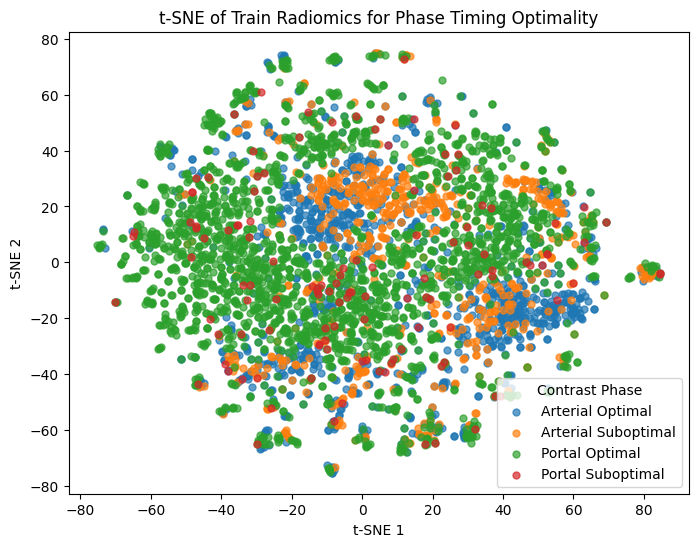

In [61]:
tsne_visual(X_train_timing, y_train_timing,optimality_le, "t-SNE of Train Radiomics for Phase Timing Optimality")

### Balanced Sampling

In [31]:
sampled_train_df = train_data_timing.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 400), random_state=42))
sampled_train_df['contrast_timing'] = sampled_train_df["contrast"].str.cat(sampled_train_df["phase_timing"], sep=" ")
sampled_train_df["contrast_timing"] = sampled_train_df["contrast_timing"].astype(str).str.strip()
sampled_train_df

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,contrast_timing
5564,NKI-d23231-00-0863_20230714_kalina99_5706.nii.gz,NKI-d23231-00-0863,Just Right,Arterial,0.519605,0.143055,-0.284556,-0.467141,-0.161839,0.613321,...,-1.296114,-0.055151,0.359804,0.425428,-1.253479,-0.617018,-0.669757,-0.464770,-0.906464,Arterial Just Right
2958,NKI-d23231-00-0338_20130903_kalina99_1810.nii.gz,NKI-d23231-00-0338,Just Right,Arterial,0.554899,0.042009,0.235115,-0.487620,-0.250020,0.469813,...,1.289559,0.003142,0.466728,0.325397,0.515018,1.086120,-0.285706,-0.837986,-0.698413,Arterial Just Right
3876,NKI-d23231-00-0460_20140825_kalina99_3122.nii.gz,NKI-d23231-00-0460,Just Right,Arterial,-0.045100,0.917742,0.439369,1.057917,-0.416817,0.063207,...,1.130084,0.221739,0.976673,0.045311,0.841353,1.537335,-0.852316,-0.571620,-0.203279,Arterial Just Right
4013,NKI-d23231-00-0483_20190405_kalina99_3380.nii.gz,NKI-d23231-00-0483,Just Right,Arterial,-0.292159,1.052470,1.069460,1.319875,-0.155924,-0.726086,...,-1.351717,1.147135,0.014357,0.105329,-0.319029,-1.417475,-2.287437,3.407689,0.416570,Arterial Just Right
4696,NKI-d23231-00-0647_20230615_kalina99_4479.nii.gz,NKI-d23231-00-0647,Just Right,Arterial,0.131370,1.945043,1.326682,1.383473,-0.143373,0.134961,...,1.490418,-0.103728,0.080156,0.105329,0.353348,1.068319,0.317947,-0.712483,-0.251813,Arterial Just Right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,NKI-d23231-00-0306_20200323_kalina99_1344.nii.gz,NKI-d23231-00-0306,Too Late,Portal,-0.327453,-0.126401,-0.247255,0.489339,-0.064215,-0.247727,...,0.122698,-0.351472,0.170630,0.105329,0.207913,-0.765995,-0.209236,-0.675986,-1.025159,Portal Too Late
3593,NKI-d23231-00-0420_20140704_kalina99_2728.nii.gz,NKI-d23231-00-0420,Too Late,Portal,-0.045100,0.109373,-0.235766,0.084086,-0.083835,0.015371,...,0.032012,-0.242173,0.121281,0.105329,0.305448,0.185420,0.005584,-0.293651,-0.209453,Portal Too Late
897,NKI-d23231-00-0105_20061013_giovanni01_0123.ni...,NKI-d23231-00-0105,Too Late,Portal,-0.115688,0.715649,1.457103,1.090468,-0.169694,-1.132692,...,-0.104442,-0.319897,-0.026768,0.105329,0.478903,-0.396867,-0.366904,1.107632,0.569409,Portal Too Late
1566,NKI-d23231-00-0193_20070726_giovanni01_0290.ni...,NKI-d23231-00-0193,Too Late,Portal,0.611370,0.156528,-0.181892,-0.318820,0.078745,0.589403,...,1.363426,-0.295608,0.162406,0.105329,-0.641640,0.035857,1.768725,-1.258632,-1.276857,Portal Too Late


In [32]:
timing_le = LabelEncoder()

X_train_timing, y_train_timing = sampled_train_df.iloc[:, 4:-1], timing_le.fit_transform(sampled_train_df.contrast_timing)
X_test_timing, y_test_timing = test_data_timing.iloc[:, 4:-1], timing_le.fit_transform(test_data_timing.contrast_timing)

print(f"Shape of train data: {X_train_timing.shape}\nShape of train labels: {y_train_timing.shape}")
print(f"Shape of test data: {X_test_timing.shape}\nShape of test labels: {y_test_timing.shape}")

Shape of train data: (1403, 212)
Shape of train labels: (1403,)
Shape of test data: (1974, 212)
Shape of test labels: (1974,)


In [33]:
models = train_tree_models(X_train_timing, y_train_timing)
predictions,_ = evaluate_model(models, X_test_timing, y_test_timing, timing_le)

Accuracy of DT: 0.73911
Accuracy of RF: 0.85512
Accuracy of GBT: 0.83536

Classification report for GBT:
                     precision    recall  f1-score   support

Arterial Just Right       0.85      0.73      0.79       493
 Arterial Too Early       0.64      0.89      0.74       248
  Arterial Too Late       0.19      0.15      0.17        33
  Portal Just Right       0.95      0.92      0.93      1148
   Portal Too Early       0.18      0.26      0.21        34
    Portal Too Late       0.12      0.17      0.14        18

           accuracy                           0.84      1974
          macro avg       0.49      0.52      0.50      1974
       weighted avg       0.85      0.84      0.84      1974



Predicted contrast,Arterial Just Right,Arterial Too Early,Arterial Too Late,Portal Just Right,Portal Too Early,Portal Too Late,All
True contrast,,,,,,,
Arterial Just Right,359,114,5,11,4,0,493
Arterial Too Early,27,220,0,1,0,0,248
Arterial Too Late,12,0,5,11,5,0,33
Portal Just Right,20,8,15,1053,30,22,1148
Portal Too Early,2,1,2,19,9,1,34
Portal Too Late,1,0,0,11,3,3,18
All,421,343,27,1106,51,26,1974


## Explanations

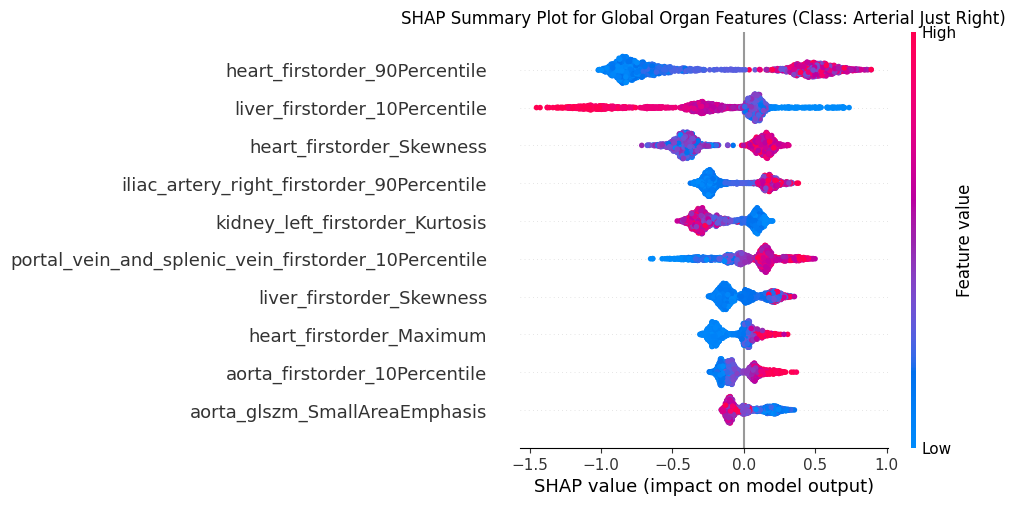

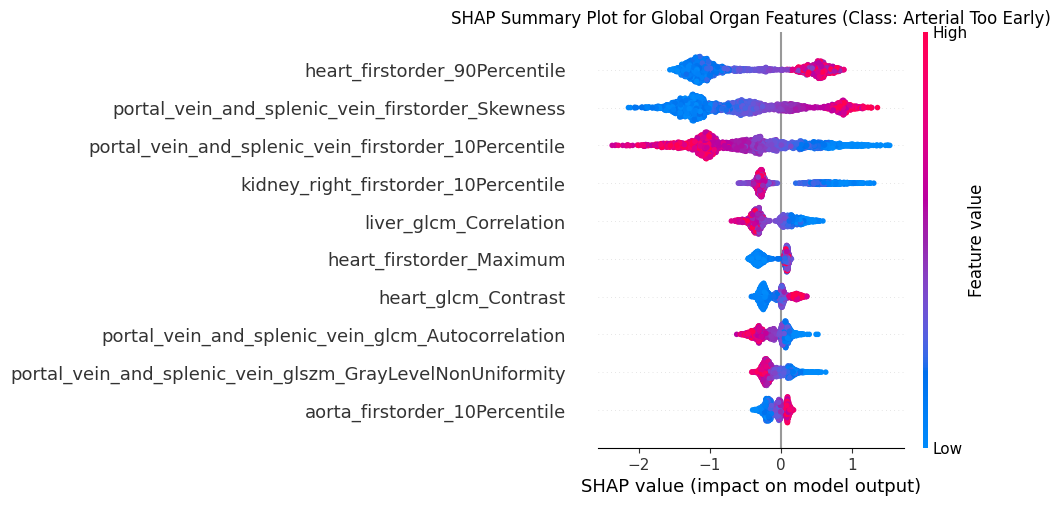

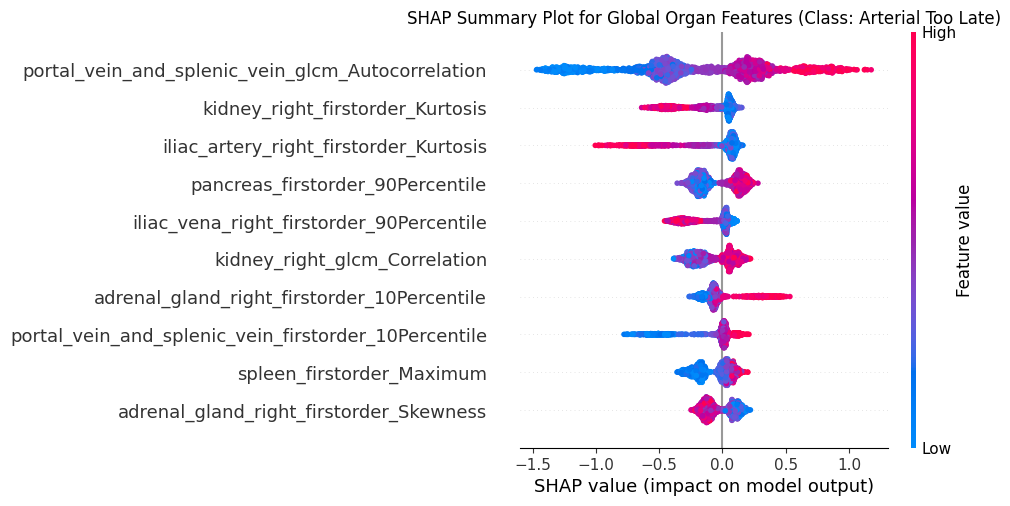

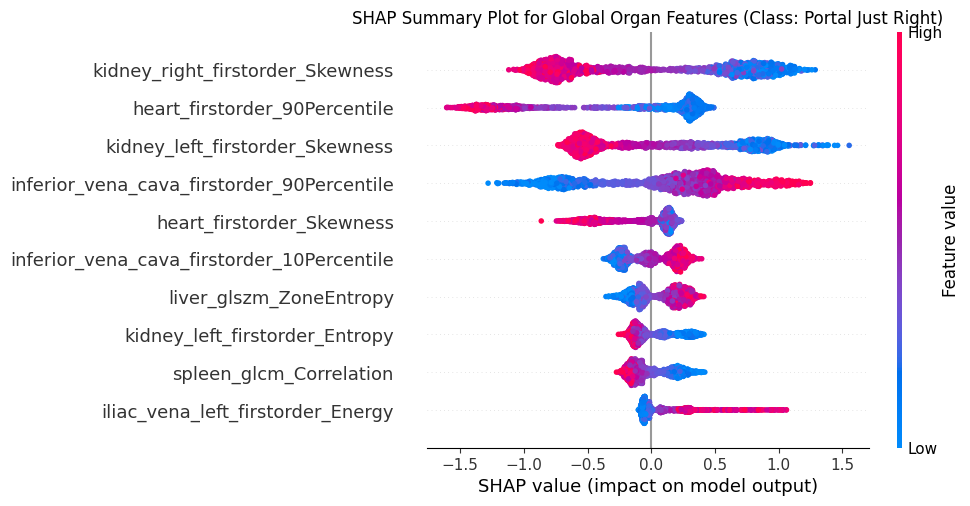

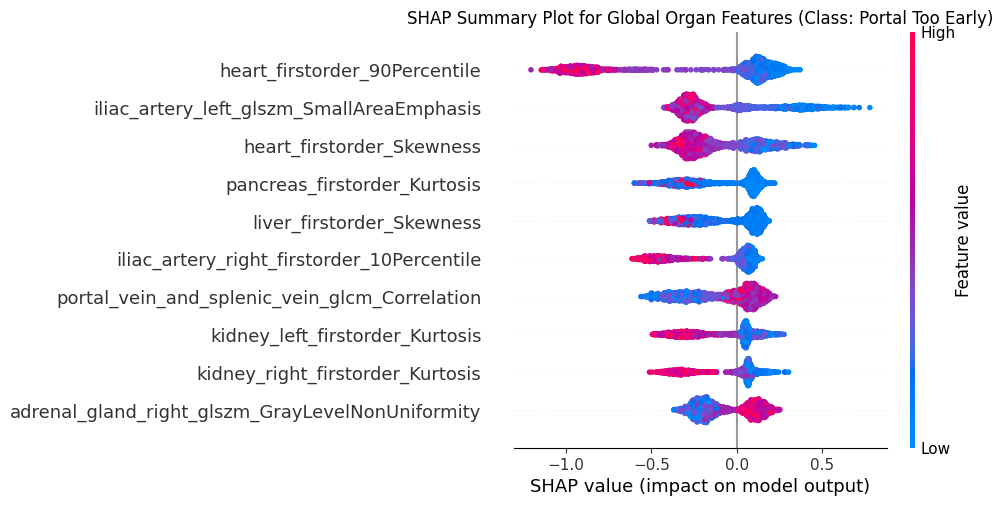

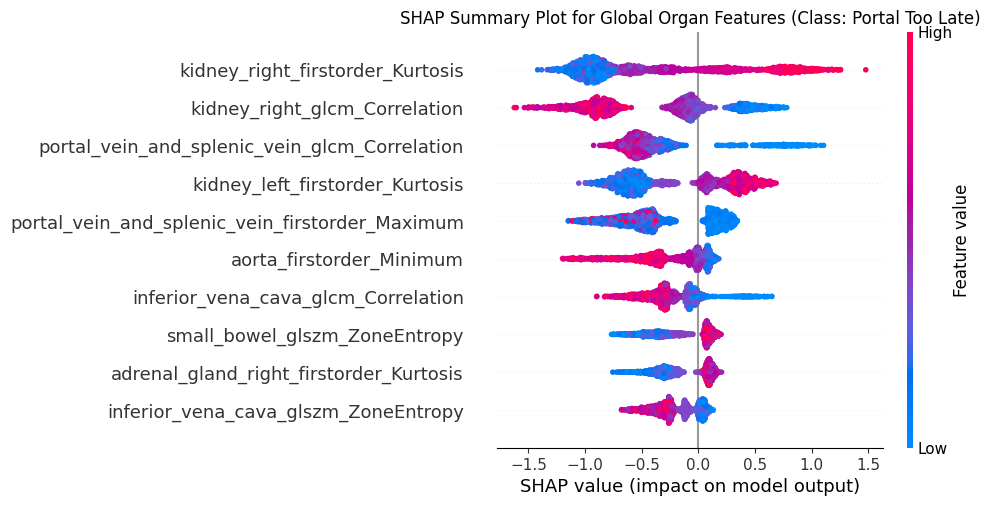

In [58]:
# GBT = models['GBT']

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_timing)


for contrast_class in range(len(timing_le.classes_)):
    shap.summary_plot(
        shap_values.values[:, :, contrast_class]
        , X_test_timing
        , max_display = 10
        , feature_names=X_test_timing.columns
        , plot_size=(10, 5)
        , show = False

    )

    plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {timing_le.classes_[contrast_class]})", fontsize=12)
    plt.show()

"Portal Too Late" relies more on Second-order features (GLCM, GLRLM, etc.):
	•	capture texture patterns
	•	are high-dimensional and noisy
	•	often become dominant when:
	•	first-order features are not discriminative
	•	model is “searching” for weak signals

For rare classes:
→ model is overfitting to weak texture patterns
→ not learning a strong physiological signal

## Misclassifications

In [46]:
# GBT_pred_timing = predictions["GBT"]

misclass_data = extract_misclass(
    y_test_timing,
    y_pred,  
    test_data_timing,  
    timing_le,                  
    X_test_timing.index                # important
)
misclass_data.head()

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,contrast_timing,pred_contrast
0,NKI-d23231-00-0005_20071116_kalina99_0005.nii.gz,NKI-d23231-00-0005,Too Late,Portal,1.084835,-0.496581,-1.055439,-2.368681,0.707978,1.378700,...,-0.538667,-0.018694,0.725633,0.040929,0.257560,-0.812183,-0.627110,-0.796870,Portal Too Late,Portal Just Right
7,NKI-d23231-00-0005_20120618_kalina12_0050.nii.gz,NKI-d23231-00-0005,Too Early,Arterial,-0.048107,-0.563977,-0.733332,-0.685196,-0.095048,0.709139,...,-0.205762,0.261138,-0.995877,0.593019,1.144063,0.078745,-0.716424,-0.336266,Arterial Too Early,Arterial Just Right
8,NKI-d23231-00-0005_20120618_kalina99_0009.nii.gz,NKI-d23231-00-0005,Too Early,Portal,0.449540,0.615457,0.039042,0.171732,-0.415085,0.565662,...,-0.208192,0.458666,-1.176035,0.585212,0.977514,0.085656,-0.617513,-0.255597,Portal Too Early,Portal Just Right
10,NKI-d23231-00-0005_20150804_kalina15_0021.nii.gz,NKI-d23231-00-0005,Just Right,Arterial,1.455424,1.188326,0.826744,0.089149,0.181125,0.852617,...,-0.157163,0.252907,-0.015016,-0.084225,0.828376,0.345143,-0.105911,0.710870,Arterial Just Right,Portal Just Right
14,NKI-d23231-00-0005_20181015_kalina03_0022.nii.gz,NKI-d23231-00-0005,Too Early,Portal,1.367188,0.615457,0.497655,-0.729938,0.242373,0.804791,...,-0.271371,-0.076307,0.165142,0.312715,1.032070,-0.409809,-0.344345,0.049263,Portal Too Early,Portal Just Right


In [21]:
show_misclass_widget(misclass_data, data, label = "contrast_timing")

interactive(children=(IntSlider(value=95, description='Slice', max=189), Output()), _dom_classes=('widget-inte…

## Visualizations

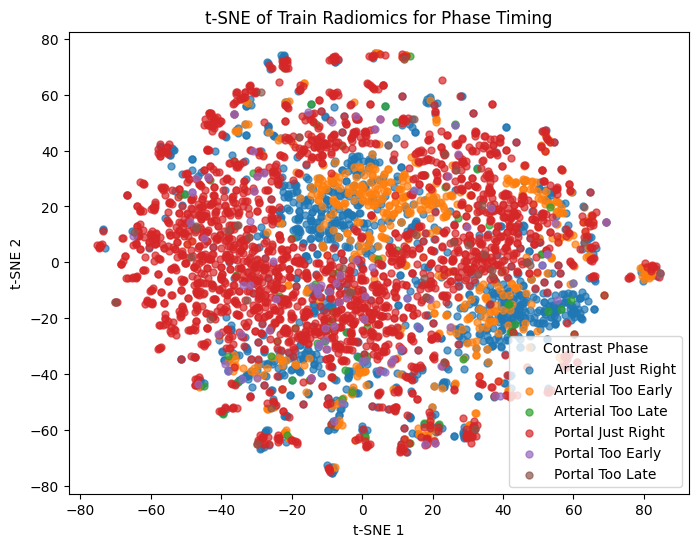

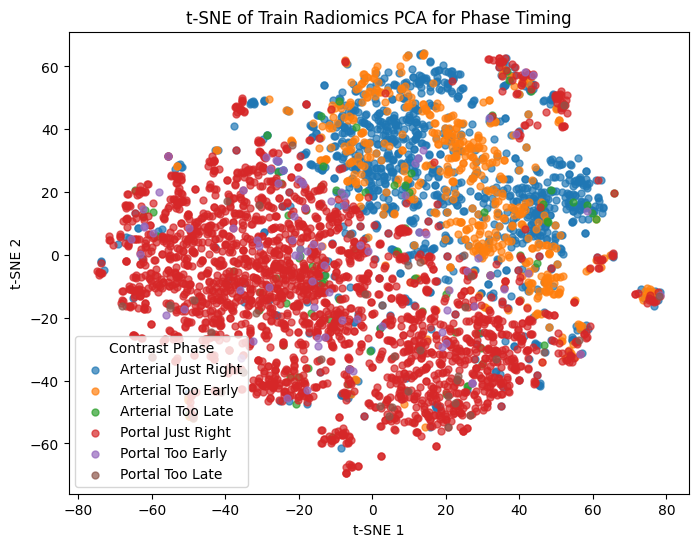

In [59]:
from sklearn.decomposition import PCA

tsne_visual(X_train_timing, y_train_timing,timing_le, "t-SNE of Train Radiomics for Phase Timing")
train_pca_timing = PCA(n_components=30, random_state = 42).fit_transform(X_train_timing)
tsne_visual(train_pca_timing, y_train_timing,timing_le, "t-SNE of Train Radiomics PCA for Phase Timing")

Radiomics features do NOT create a clean separation between timing classes
Especially:
	•	Early vs optimal vs late are not forming distinct manifolds
	•	Minority classes are embedded inside majority regions

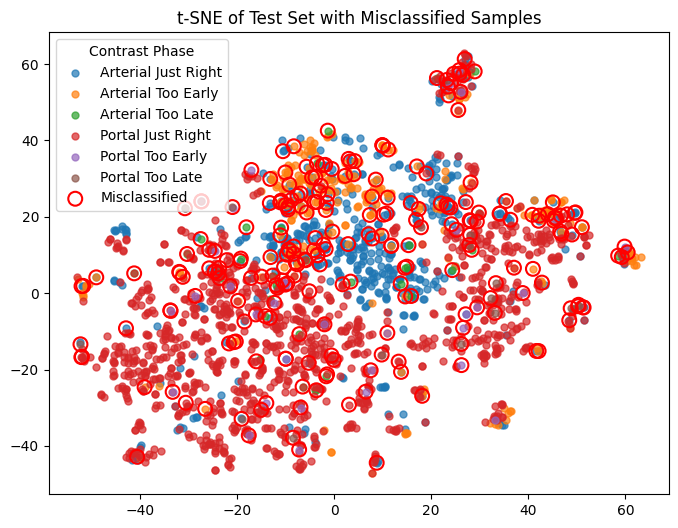

In [48]:
test_pca_timing = PCA(n_components=30, random_state = 42).fit_transform(X_test_timing)


tsne_visual(test_pca_timing,
            y_test_timing,
            timing_le,
            "t-SNE of Test Radiomics PCA for Phase Timing",
            misclassifications=True,
            predictions=y_pred)

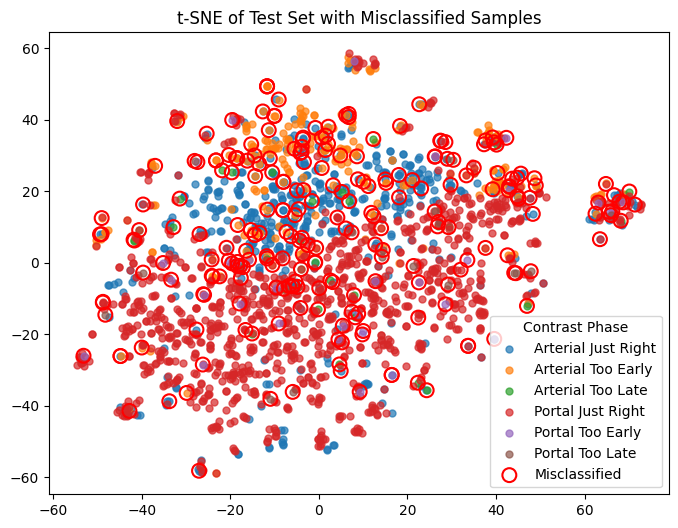

In [ ]:
tsne_visual(X_test_timing,
            y_test_timing,
            timing_le,
            "t-SNE of Test Radiomics for Phase Timing",
            misclassifications=True,
            predictions=GBT_pred)

# Hierarchical Contrast Timing Classification

## AP vs PVP -> multiclass

In [42]:
# contrast phase
#     ├── arterial
#     │     ├── too early
#     │     ├── just right
#     │     └── too late
#     └── portal
#           ├── too early
#           ├── just right
#           └── too late

In [43]:
train_data_timing

,image,SubjectKeyRadiology,phase_timing,contrast,adrenal_gland_left_firstorder_10Percentile,adrenal_gland_left_firstorder_90Percentile,adrenal_gland_left_firstorder_Energy,adrenal_gland_left_firstorder_Entropy,adrenal_gland_left_firstorder_Kurtosis,adrenal_gland_left_firstorder_Minimum,...,stomach_firstorder_Entropy,stomach_firstorder_Maximum,stomach_firstorder_Median,stomach_firstorder_Minimum,stomach_glcm_Correlation,stomach_glszm_ZoneEntropy,stomach_glszm_SmallAreaEmphasis,stomach_glszm_GrayLevelNonUniformity,stomach_glszm_SizeZoneNonUniformity,contrast_timing
0,NKI-d23231-00-0001_20060920_kalina12_0045.nii.gz,NKI-d23231-00-0001,Too Early,Portal,0.308363,0.446967,0.230648,0.362596,-0.242303,0.206969,...,0.099530,0.107703,0.285829,0.105089,0.894737,0.592513,-0.626645,0.798799,0.715094,Portal Too Early
1,NKI-d23231-00-0001_20070608_kalina03_0023.nii.gz,NKI-d23231-00-0001,Just Right,Portal,0.767188,0.581759,0.806248,0.061035,-0.227770,0.589575,...,1.079447,0.737064,0.450436,0.105089,0.449950,1.375772,-0.344830,-0.135113,0.433511,Portal Just Right
3,NKI-d23231-00-0001_20070815_kalina14_0007.nii.gz,NKI-d23231-00-0001,Just Right,Portal,0.978952,-0.159600,0.197907,-1.205143,0.162089,1.665654,...,-1.237660,-0.368570,0.318750,1.186037,-0.210362,0.629883,-1.886213,-0.836511,-1.148070,Portal Just Right
4,NKI-d23231-00-0001_20070815_kalina99_0000.nii.gz,NKI-d23231-00-0001,Just Right,Portal,0.943658,0.244778,0.775801,-0.413095,0.711832,0.135230,...,-0.284283,-0.174173,0.326981,1.005879,-0.271568,1.287666,-1.755195,-0.956994,-1.073037,Portal Just Right
5,NKI-d23231-00-0001_20070815_kalina99_0001.nii.gz,NKI-d23231-00-0001,Just Right,Portal,0.484834,-0.260694,-0.110524,-0.743531,0.187050,1.235223,...,-1.226551,-0.344270,0.326981,1.065932,-1.068552,0.874984,-2.057478,-0.917569,-1.166181,Portal Just Right
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5667,NKI-d23231-00-0888_20220420_kalina99_5827.nii.gz,NKI-d23231-00-0888,Just Right,Portal,0.908364,0.952439,0.314040,0.367358,0.137988,-0.199550,...,0.294838,-0.317540,0.005997,0.105089,0.196472,0.255930,0.114496,-0.262090,-0.163259,Portal Just Right
5668,NKI-d23231-00-0888_20230424_kalina99_5828.nii.gz,NKI-d23231-00-0888,Just Right,Arterial,0.566011,-0.493211,-1.243993,-0.979812,1.996222,1.306961,...,-0.385355,-0.217912,0.401054,0.105089,-2.561788,-0.739318,-1.743220,-0.300341,-0.953126,Arterial Just Right
5669,NKI-d23231-00-0888_20230424_kalina99_5829.nii.gz,NKI-d23231-00-0888,Just Right,Portal,0.378952,-0.648223,-1.236682,-1.014415,3.009639,1.761306,...,-0.497723,-0.220342,0.384593,0.105089,-1.275965,-0.648691,-0.806422,-0.367169,-0.882091,Portal Just Right
5670,NKI-d23231-00-0888_20230801_kalina99_5830.nii.gz,NKI-d23231-00-0888,Just Right,Arterial,0.851894,2.462115,-1.284141,0.551022,0.397372,2.885211,...,-0.834574,-0.171743,0.738498,0.305264,-3.205634,-1.370901,-3.655472,-0.224134,-1.198989,Arterial Just Right


In [44]:
contrast_le = LabelEncoder()

phase_mapping = {"Too Early": 0,
                 "Just Right": 1,
                 "Too Late": 2
                 }



X_train, y_train = train_data_timing.iloc[:, 4:-1], contrast_le.fit_transform(train_data_timing.contrast)
X_test, y_test = test_data_timing.iloc[:, 4:-1], contrast_le.fit_transform(test_data_timing.contrast)

y_train_timing = np.array(train_data_timing.phase_timing.map(phase_mapping))
y_test_timing = np.array(test_data_timing.phase_timing.map(phase_mapping))

In [45]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
print(X_train.shape, y_train_timing.shape, X_test.shape, y_test_timing.shape)
print("Contrast labels:",set(y_train),"Timing labels:", set(y_train_timing))
print("Contrast test labels:",set(y_test),"Timing test labels:", set(y_test_timing))

(4213, 212) (4213,) (1976, 212) (1976,)
(4213, 212) (4213,) (1976, 212) (1976,)
Contrast labels: {np.int64(0), np.int64(1)} Timing labels: {np.int64(0), np.int64(1), np.int64(2)}
Contrast test labels: {np.int64(0), np.int64(1)} Timing test labels: {np.int64(0), np.int64(1), np.int64(2)}


In [46]:
from xgboost import XGBRegressor

# Binary model
binary_contrast_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    tree_method="hist",
    eval_metric="mlogloss",
    random_state=42
)

# Arterial model
arterial_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    random_state=0
)

# Portal model
portal_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    random_state=0
)

binary_contrast_model.fit(X_train, y_train)

X_train_art = X_train[y_train == 0]
y_train_art = y_train_timing[y_train == 0]
arterial_model.fit(X_train_art, y_train_art)
print(np.mean(y_train_art == 0))
print(np.mean(y_train_art == 2))


X_train_port = X_train[y_train == 1]
y_train_port = y_train_timing[y_train == 1]
portal_model.fit(X_train_port, y_train_port)
print(np.mean(y_train_port == 0))
print(np.mean(y_train_port == 2))

final_predictions = []

for i in range(len(X_test)):

    phase = binary_contrast_model.predict(X_test.iloc[[i]])[0]
    
    if phase == 0:
        timing = arterial_model.predict(X_test.iloc[[i]])[0]
        timing = np.clip(np.round(timing), 0, 2).astype(int)
    else:
        timing = portal_model.predict(X_test.iloc[[i]])[0]
        timing = np.clip(np.round(timing), 0, 2).astype(int)


    final_predictions.append(f"{phase} {timing}")

0.32201405152224827
0.04800936768149883
0.03313373253493014
0.015968063872255488


In [47]:
# Inverse the labeling of the predicted labels
inverse_phase_mapping = {v: k for k, v in phase_mapping.items()}

pairs = [tuple(map(int, s.split())) for s in final_predictions]

contrast_ids = [c for c, t in pairs]
timing_ids = [t for c, t in pairs]

contrast_labels = contrast_le.inverse_transform(contrast_ids)
timing_labels = [inverse_phase_mapping[i] for i in timing_ids]

final_predictions_decoded = list(zip(contrast_labels, timing_labels))
final_predictions_decoded = [' '.join(map(str, t)) for t in final_predictions_decoded]

# Inverse the labeling of the true labels
true_comb_labels  = list(zip(contrast_le.inverse_transform(y_test), [inverse_phase_mapping[i] for i in y_test_timing]))
true_comb_labels = [' '.join(map(str, t)) for t in true_comb_labels]

In [48]:
print(classification_report(true_comb_labels, final_predictions_decoded))
display(pd.crosstab(
    true_comb_labels,
    final_predictions_decoded,
    rownames=["True contrast"],
    colnames=["Predicted contrast"],
    margins=True
))

                     precision    recall  f1-score   support

Arterial Just Right       0.83      0.84      0.83       493
 Arterial Too Early       0.75      0.75      0.75       248
  Arterial Too Late       0.60      0.09      0.16        33
  Portal Just Right       0.93      0.99      0.96      1150
   Portal Too Early       0.33      0.03      0.05        34
    Portal Too Late       0.33      0.06      0.10        18

           accuracy                           0.88      1976
          macro avg       0.63      0.46      0.47      1976
       weighted avg       0.86      0.88      0.86      1976



Predicted contrast,Arterial Just Right,Arterial Too Early,Arterial Too Late,Portal Just Right,Portal Too Early,Portal Too Late,All
True contrast,,,,,,,
Arterial Just Right,412,61,0,19,1,0,493
Arterial Too Early,62,185,0,1,0,0,248
Arterial Too Late,13,0,3,17,0,0,33
Portal Just Right,8,1,1,1137,1,2,1150
Portal Too Early,1,0,1,31,1,0,34
Portal Too Late,2,0,0,15,0,1,18
All,498,247,5,1220,3,3,1976


In [49]:
# misclass_data = extract_misclass(
#     y_test,
#     contrast_pred,  
#     test_data_timing,  
#     contrast_le,                  
#     X_test.index                # important
# )
# misclass_data.contrast_timing.value_counts()

# PCA

In [27]:
from data_preprocessing import PCA_formatting
train_pca = PCA_formatting(X_train_pca, train_processed)
test_pca = PCA_formatting(X_test_pca, test_processed)

train_pca

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,PCA_10,...,PCA_21,PCA_22,PCA_23,PCA_24,PCA_25,PCA_26,PCA_27,PCA_28,PCA_29,PCA_30
0,1.125082,1.900427,0.194411,4.139634,-1.792700,0.319090,1.195311,0.664961,0.900958,0.648036,...,-0.255754,-0.249238,-0.705738,-0.654281,0.056165,1.341792,0.087289,-0.099210,-0.072117,0.591430
1,2.336418,0.702817,-0.774617,3.655397,-1.102603,0.223994,1.009821,0.924799,2.303150,0.480098,...,0.913020,1.108655,0.641111,0.285391,1.821488,-0.311680,-0.572512,0.600429,-0.312925,-0.180124
2,-4.661348,-7.623607,-4.377060,0.850455,-0.291278,0.359849,-1.942701,-0.223482,4.909420,2.897639,...,11.539871,6.147245,-2.091090,2.096970,4.878554,-0.829594,-3.738071,5.182501,1.380057,-0.231077
3,7.875120,-5.150695,-2.217713,2.371615,-0.780846,-1.207076,0.460775,0.250638,-1.514827,-1.418813,...,0.791292,0.731770,0.449121,0.348418,-0.667677,0.188351,-0.358158,-0.504446,-0.930938,-0.241793
4,8.864310,-4.360372,-7.803318,4.459831,-1.153244,-0.565291,-3.969503,-0.998518,-1.171573,-0.837713,...,0.247083,0.615173,-0.077550,-1.967564,-1.418988,-0.620940,0.421506,-1.454219,-0.292150,0.369185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5667,-0.103470,-0.123065,3.504716,2.099608,0.098718,-0.876874,0.766058,-1.193370,0.923795,0.023729,...,-0.532332,-0.669089,-0.931125,-0.529781,0.135744,0.007396,-0.142294,0.333731,-0.356360,0.812259
5668,4.619964,4.001494,0.140830,-1.838469,-1.012041,1.832476,0.726162,-3.109308,0.242573,-0.292859,...,-0.290698,-1.053166,0.840183,0.935580,-1.730760,-1.654599,-1.383162,-1.203538,0.586750,1.752333
5669,2.972664,0.598667,2.699444,2.730616,2.114768,0.244747,1.804674,-2.639588,0.493162,-0.003797,...,-0.851318,-1.188763,0.061746,0.932522,-1.027601,-1.276936,-1.135877,-1.124996,0.502199,0.279688
5670,7.806028,8.191723,-2.965057,0.875650,-0.503895,2.543795,0.856054,-3.782109,-0.975067,-0.716310,...,-0.161766,-1.748410,1.367689,0.898661,-2.172375,-2.011756,-1.516968,-1.029458,1.006128,1.853044


In [28]:
print(f"Shape of train data: {train_pca.shape}\nShape of train labels: {y_train.shape}")
print(f"Shape of test data: {test_pca.shape}\nShape of test labels: {y_test.shape}")

Shape of train data: (5672, 30)
Shape of train labels: (5672,)
Shape of test data: (2661, 30)
Shape of test labels: (2661,)


In [29]:
models = train_tree_models(train_pca, y_train)
predictions = evaluate_model(models, test_pca, y_test, contrast_le)

Accuracy of DT: 0.91432
Accuracy of RF: 0.92672
Accuracy of GBT: 0.95566

Classification report for GBT:
              precision    recall  f1-score   support

    Arterial       0.94      0.92      0.93       776
Non-contrast       0.99      0.98      0.99       683
      Portal       0.94      0.96      0.95      1202

    accuracy                           0.96      2661
   macro avg       0.96      0.96      0.96      2661
weighted avg       0.96      0.96      0.96      2661



Predicted contrast,Arterial,Non-contrast,Portal,All
True contrast,,,,
Arterial,715,2,59,776
Non-contrast,3,670,10,683
Portal,40,4,1158,1202
All,758,676,1227,2661


In [ ]:
# GBT = models['GBT']

# explainer = shap.TreeExplainer(GBT)
# shap_values = explainer(train_pca)


# for contrast_class in range(len(contrast_le.classes_)):
#     shap.summary_plot(
#         shap_values.values[:, :, contrast_class]
#         , train_pca
#         , max_display = 10
#         , feature_names=train_pca.columns
#         , plot_size=(10, 5)
#         , show = False
#         # , order=shap_values.abs.max(0)
#     )

#     plt.title(f"SHAP Summary Plot for Global Organ Features (Class: {contrast_le.classes_[contrast_class]})", fontsize=12)
#     plt.show()